In [26]:
import copy
import h5py
import os
import numpy as np
import scipy
import sncosmo
from PIL import Image
import galsim
from astropy.cosmology import WMAP9 as cosmo
import matplotlib.pyplot as plt

from astropy.table import Table
# make sure lenstronomy is installed, otherwise install the latest pip version
try:
    import lenstronomy
except:
    get_ipython().system('pip install lenstronomy')
from astropy.io import fits
from astropy import wcs
import galsim

# lenstronomy module import
from lenstronomy.Util import image_util, data_util, util
import lenstronomy.Plots.plot_util as plot_util
from lenstronomy.SimulationAPI.sim_api import SimAPI
from lenstronomy.Plots.plot_util import coordinate_arrows, scale_bar
from lenstronomy.SimulationAPI.point_source_variability import PointSourceVariability

from astropy.table import Table
import sncosmo

# import NGC1300 jpg image and decompose it
import imageio.v2 as imageio
from scipy.ndimage import gaussian_filter
from lenstronomy.Cosmo.micro_lensing import einstein_radius

import matplotlib as mpl
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'serif'

In [27]:
def simulate_rgb(ConfigList, size, kwargs_numerics, time, source_x=0,source_y=0,returnsqrt = False):
    band_g, band_r, band_i = ConfigList
    kwargs_i_band = band_i.kwargs_single_band()
    kwargs_g_band = band_g.kwargs_single_band()
    kwargs_r_band = band_r.kwargs_single_band()
    #print(kwargs_b_band) #'pixel_scale' : kwargs_b_band['pixel_scale']
    # set number of pixels from pixel scale
    pixel_scale = kwargs_g_band['pixel_scale']
    numpix = int(round(size / pixel_scale))
    #kwargs_model['pixel_scale'] = kwargs_b_band['pixel_scale']
    sim_i = SimAPI(numpix=numpix, kwargs_single_band=kwargs_i_band, kwargs_model=kwargs_model_time_var)
    sim_g = SimAPI(numpix=numpix, kwargs_single_band=kwargs_g_band, kwargs_model=kwargs_model_time_var)
    sim_r = SimAPI(numpix=numpix, kwargs_single_band=kwargs_r_band, kwargs_model=kwargs_model_time_var)

    # return the ImSim instance. With this class instance, you can compute all the
    # modelling accessible of the core modules. See class documentation and other notebooks.
    imSim_i = sim_i.image_model_class(kwargs_numerics)
    imSim_g = sim_g.image_model_class(kwargs_numerics)
    imSim_r = sim_r.image_model_class(kwargs_numerics)


    # turn magnitude kwargs into lenstronomy kwargs
    kwargs_lens_light_g, kwargs_source_g, kwargs_ps_g = sim_g.magnitude2amplitude(kwargs_lens_light_mag_g, kwargs_source_mag_g, kwargs_ps_mag_g)
    kwargs_lens_light_r, kwargs_source_r, kwargs_ps_r = sim_g.magnitude2amplitude(kwargs_lens_light_mag_r, kwargs_source_mag_r, kwargs_ps_mag_r)
    kwargs_lens_light_i, kwargs_source_i, kwargs_ps_i = sim_r.magnitude2amplitude(kwargs_lens_light_mag_i, kwargs_source_mag_i, kwargs_ps_mag_i)

    ps_var_g = PointSourceVariability(source_x, source_y, var_func_g, numpix, kwargs_g_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_g, kwargs_lens_light_mag_g, kwargs_ps_mag=kwargs_ps_mag_g)

    ps_var_r = PointSourceVariability(source_x, source_y, var_func_r, numpix, kwargs_r_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_r, kwargs_lens_light_mag_r, kwargs_ps_mag=kwargs_ps_mag_r)

    ps_var_i = PointSourceVariability(source_x, source_y, var_func_i, numpix, kwargs_i_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_i, kwargs_lens_light_mag_i, kwargs_ps_mag=kwargs_ps_mag_i)
    
    # delays = ps_var_g.delays
    # print('DELAYS',delays) #,np.max(delays))

    image_g = ps_var_g.image_time(time=time)#imSim_b.image(kwargs_lens, kwargs_source_g, kwargs_lens_light_g, kwargs_ps_g)
    image_r = ps_var_r.image_time(time=time)#imSim_g.image(kwargs_lens, kwargs_source_r, kwargs_lens_light_r, kwargs_ps_r)
    image_i = ps_var_i.image_time(time=time)#imSim_r.image(kwargs_lens, kwargs_source_i, kwargs_lens_light_i, kwargs_ps_i)

    # add noise
    image_i += sim_i.noise_for_model(model=image_i)
    image_g += sim_g.noise_for_model(model=image_g)
    image_r += sim_r.noise_for_model(model=image_r)

    # and plot it

    img = np.zeros((image_g.shape[0], image_g.shape[1], 3), dtype=float)
    #scale_max=10000
    def _scale_max(image): 
        flat=image.flatten()
        flat.sort()
        scale_max = flat[int(len(flat)*0.95)]
        return scale_max
    if returnsqrt==True:
        img[:,:,0] = plot_util.sqrt(image_g, scale_min=0, scale_max=_scale_max(image_g))
        img[:,:,1] = plot_util.sqrt(image_r, scale_min=0, scale_max=_scale_max(image_r))
        img[:,:,2] = plot_util.sqrt(image_i, scale_min=0, scale_max=_scale_max(image_i))
    else:
        img[:,:,0] = image_i
        img[:,:,1] = image_g
        img[:,:,2] = image_r
        
    data_class = sim_i.data_class

    return img, data_class, [ps_var_g, ps_var_r, ps_var_i]



In [28]:

nbands = 3
nepochs = 15
bands = ['lsstg', 'lsstr', 'lssti']

# ## Define camera and observations
# As an example, we define the camera and observational settings of a LSST-like observation. We define one camera setting and three different observations corresponding to g,r,i imaging.
# For the complete list of possible settings, we refer to the SimulationAPI.observation_api classes. There are pre-configured settings which approximately mimic observations from current and future instruments. Be careful using those and check whether they are sufficiently accurate for your specific science case!

# Instrument setting from pre-defined configurations

from lenstronomy.SimulationAPI.ObservationConfig.DES import DES
#from lenstronomy.SimulationAPI.ObservationConfig.LSSTsingleobs import LSST
from lenstronomy.SimulationAPI.ObservationConfig.LSST import LSST

from lenstronomy.SimulationAPI.ObservationConfig.Euclid import Euclid
from lenstronomy.SimulationAPI.ObservationConfig.Roman import Roman

DES_g = DES(band='g', psf_type='GAUSSIAN', coadd_years=3)
DES_r = DES(band='r', psf_type='GAUSSIAN', coadd_years=3)
DES_i = DES(band='i', psf_type='GAUSSIAN', coadd_years=3)
des = [DES_g, DES_r, DES_i]

LSST_g = LSST(band='g', psf_type='GAUSSIAN', coadd_years=10)
LSST_r = LSST(band='r', psf_type='GAUSSIAN', coadd_years=10)
LSST_i = LSST(band='i', psf_type='GAUSSIAN', coadd_years=10)
lsst = [LSST_g, LSST_r, LSST_i]

Roman_g = Roman(band='F062', psf_type='PIXEL', survey_mode='wide_area')
Roman_r = Roman(band='F106', psf_type='PIXEL', survey_mode='wide_area')
Roman_i = Roman(band='F184', psf_type='PIXEL', survey_mode='wide_area')#'single_exposure')#'wide_area')
roman = [Roman_g, Roman_r, Roman_i]
LS4_g_band_obs = {'exposure_time': 15.,  # exposure time per image (in seconds)
                   'sky_brightness': 22.26,  # sky brightness (in magnitude per square arcseconds)
                   'magnitude_zero_point': 28.30,  # magnitude in which 1 count per second per arcsecond square is registered (in ADU's)
                   'num_exposures': 30,  # number of exposures that are combined
                   'seeing': 1.5,  # full width at half maximum of the PSF (if not specific psf_model is specified)
                   'psf_type': 'GAUSSIAN',  # string, type of PSF ('GAUSSIAN' and 'PIXEL' supported)
                   'kernel_point_source': None  # 2d numpy array, model of PSF centered with odd number of pixels per axis (optional when psf_type='PIXEL' is chosen)
                  }

LS4_r_band_obs = {'exposure_time': 15.,
                   'sky_brightness': 21.2,
                   'magnitude_zero_point': 28.13,
                   'num_exposures': 30,
                   'seeing': 1.5,
                   'psf_type': 'GAUSSIAN'}

LS4_i_band_obs = {'exposure_time': 15.,
                   'sky_brightness': 20.48,
                   'magnitude_zero_point': 27.79,
                   'num_exposures': 30,
                   'seeing': 1.5,
                   'psf_type': 'GAUSSIAN'}

LS4_camera = {'read_noise': 10,  # std of noise generated by read-out (in units of electrons)
               'pixel_scale': 1.0,  # scale (in arcseonds) of pixels
               'ccd_gain': 4.5  # electrons/ADU (analog-to-digital unit). A gain of 8 means that the camera digitizes the CCD signal so that each ADU corresponds to 8 photoelectrons.
              }
# lenstronomy provides these setting to be imported with the SimulationAPI.ObservationConfig routines.

kwargs_g_band_LS4 = util.merge_dicts(LS4_camera, LS4_g_band_obs)
kwargs_r_band_LS4 = util.merge_dicts(LS4_camera, LS4_r_band_obs)
kwargs_i_band_LS4 = util.merge_dicts(LS4_camera, LS4_i_band_obs)
kwargs_LS4 = [kwargs_g_band_LS4,kwargs_r_band_LS4,kwargs_i_band_LS4]



In [29]:
def var_func(time, zero_point, band, z_source): #band either desg, desi, desr
    if z_source > 0.915:
        z_source = 0.915
    
    obs = Table({'time': [time],
             'band': [band],          #filters we are observing in
             'gain': [1.0],              #dw
             'skynoise': [0],           #depends on exposure time, but will be addig noise later in lenstronomy, could set to 0
             'zp': [zero_point],        # zero point, what corresponds to 0 flux in this image - pixel values to magnitudes
             'zpsys':['ab']})           # ab magnitudes, units of zero point

    model = sncosmo.Model(source='salt2')
    params = {'z': 0, 't0': 56200.0, 'x0':1.e-5, 'x1': 0.1, 'c': -0.1}

    lcs = sncosmo.realize_lcs(obs, model, [params])
    flux = np.array(lcs[0]['flux'])
    # print(lcs[0]['time'])
    # print(flux)
    zero_points = np.array(obs['zp'])
    magnitude = zero_points - 2.5 * np.log10(flux)
    # print(time,magnitude)
    # return flux
    return magnitude

var_func_g = lambda t: var_func(t, 28.30, 'lsstg', z_source)
var_func_r = lambda t: var_func(t, 28.13, 'lsstr', z_source)
var_func_i = lambda t: var_func(t, 27.7, 'lssti', z_source)



TIME  56150
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56152
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56154
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56156
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56158
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56160
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56162
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56164
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56166
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56168
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56170
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56172
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56174
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56176
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56178
DELAYS [ 0.         11

/tmp/ipykernel_1358449/2922409724.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_1358449/2922409724.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_1358449/2922409724.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_1358449/2922409724.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_1358449/2922409724.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_1358449/2922409724.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)


TIME  56190
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56192
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56194
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56196
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56198
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372


/tmp/ipykernel_1358449/2922409724.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)


TIME  56200
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56202
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56204
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56206
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56208
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56210
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56212
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56214
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56216
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56218
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56220
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56222
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56224
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56226
DELAYS [ 0.         11.38141263]
SEP  0.5576468441110372
TIME  56228
DELAYS [ 0.         11

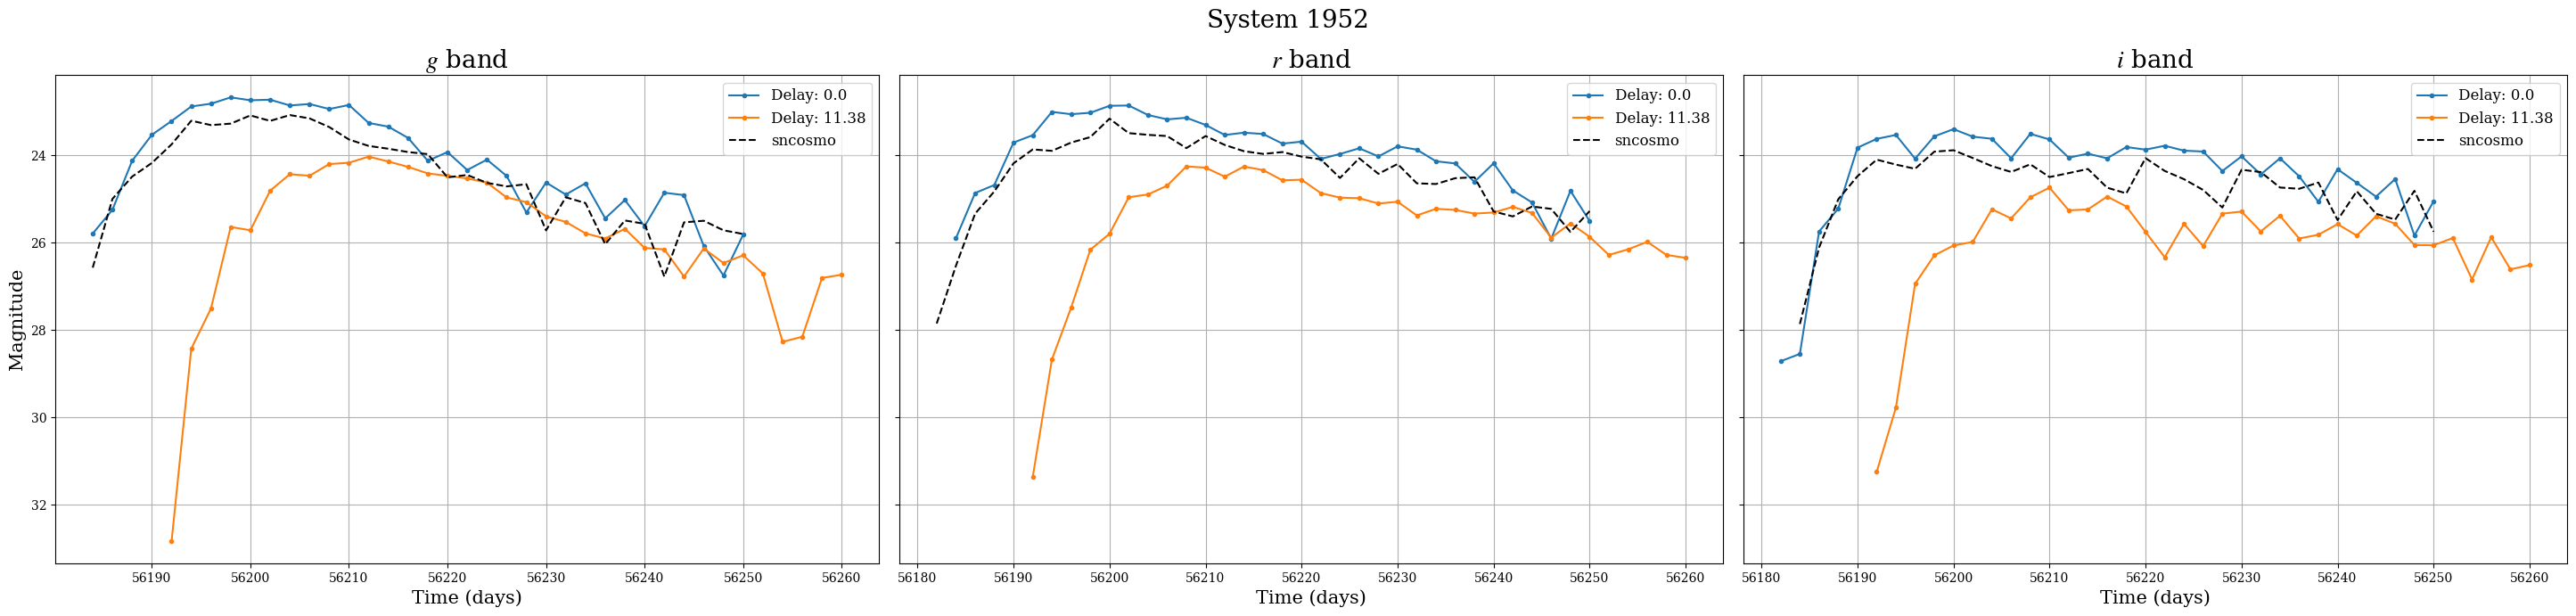

In [31]:

f = h5py.File('lsst-altsched-1a-lowz.h5','r')
simitems = np.asarray(f['system']['block0_items'][()],dtype=str)
simdataall = f['system']['block0_values'][()]
# print(simdataall[0],simitems)


#This is where I match to that table I provided by redshift. You'll want to replace this with a search for the time delay parameter and match by that!
indcatalog = [146401, 134600, 
              17462, 129533, 
              96679, 158021,
              124869, 36820,
              21540, 210563]

indcatalog = [1952] #201325
times = np.arange(56150,56350,2)

import warnings
np.seterr(divide='ignore')  
warnings.filterwarnings("ignore", message="Astropy Cosmology is provided. Make sure your cosmology model is consistent with the cosmology_model argument.")

for ind in indcatalog:
    simdata=simdataall[ind]
    z_lens = simdata[simitems == "zl"][0]
    z_source = simdata[simitems == "zs"][0]
    # print('z les',z_lens,'z source',z_source)
    kwargs_model_time_var = {'lens_model_list': ['SIE', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],#['INTERPOL'],  # list of extended source models to be used, here we used the interpolated real galaxy
                'point_source_model_list': ['SOURCE_POSITION'],  # list of point source models to be used
                'z_lens': z_lens, 
                         'z_source': z_source
    } 
    Dl = cosmo.angular_diameter_distance(simdata[simitems == "zl"][0]).value
    Ds = cosmo.angular_diameter_distance(simdata[simitems == "zs"][0]).value
    Dls = cosmo.angular_diameter_distance_z1z2(simdata[simitems == "zl"][0],simdata[simitems == "zs"][0]).value
 
    theta_E_sim = simdata[simitems == "theta_e"][0]
    lens_reff = simdata[simitems == "lensgal_reff"][0]
    lens_n = simdata[simitems == "lensgal_n"][0]
    lens_theta = simdata[simitems == "lensgal_theta"][0]
    lens_ellip = simdata[simitems == "lensgal_ellip"][0]
    s = galsim.Shear(e=lens_ellip, beta=lens_theta*galsim.degrees)
    lens_e1 = s.e1
    lens_e2 = s.e2
   
    lens_gamma = simdata[simitems == "gamma"][0]
    gamma_theta = simdata[simitems == "theta_gamma"][0]
    lens_g1 = np.sin(gamma_theta*np.pi/180)*lens_gamma
    lens_g2 = np.cos(gamma_theta*np.pi/180)*lens_gamma
    lens_x = simdata[simitems == "lensgal_x"][0]
    lens_y = simdata[simitems == "lensgal_y"][0]

    host_reff = simdata[simitems == "host_reff"][0]
    host_n = simdata[simitems == "host_n"][0]
    host_theta = simdata[simitems == "host_theta"][0]
    host_ellip = simdata[simitems == "host_ellip"][0]
    try:
        sh = galsim.Shear(e=host_ellip, beta=host_theta*galsim.degrees)
    except:
        continue
    host_e1 = sh.e1
    host_e2 = sh.e2
    host_x = simdata[simitems == "host_x"][0]
    host_y = simdata[simitems == "host_y"][0]
    sn_x = simdata[simitems == "snx"][0]
    sn_y = simdata[simitems == "sny"][0]

    #My failed attempts to extract a meaningful magnitude from whatever units Danny was using
    '''
    lens_amp = 22.5-2.5*np.log10(simdata[simitems == "lensgal_amplitude"][0])
    mu = -2.5*np.log(simdata[simitems == "lensgal_amplitude"][0])
    mag = mu - np.log10(2*np.pi*host_reff*60*60/180*np.pi*1e3)-36.57#mu - 5*np.log10(lens_reff/(Dl/60/60))-2.5*np.log10(2*np.pi)+10*np.log10(1+simdata[simitems == "zl"][0])
    print('MAG',mag,host_reff)
    print('VMAG',-2.5*np.log10(simdata[simitems == "lensgal_amplitude"][0])-48.6)
    host_amp = 22.5-2.5*np.log10(simdata[simitems == "host_amplitude"][0])
    print(str(simitems),'lens_amp',lens_amp,'host_amp',host_amp,simdata[simitems == "lensgal_amplitude"][0])
    '''
    
    magdiff = 2.5*(np.log10(simdata[simitems == "lensgal_amplitude"][0])-np.log10(simdata[simitems == "host_amplitude"][0]))
   
    magdiffps = 2.5*(np.log10(simdata[simitems == "lensgal_amplitude"][0])-np.log10(simdata[simitems == "transient_amplitude"][0]))
  
    sig = simdata[simitems == "sigma"][0]
    theta_E = 4*np.pi*(sig/3e5)**2*Dls/Ds*180/np.pi*60*60
    M0=1.9*(sig/200)**5.1*1e8
    Mstar= 10**((np.log10(M0)-7.45)/1.05)*1e11
 
    radius = einstein_radius(Mstar, Dl*1e6, Ds*1e6)

    kwargs_lens = [
        {'theta_E': theta_E, 'e1': lens_e1, 'e2': lens_e2, 'center_x': lens_x, 'center_y': lens_y},  # SIE model
        {'gamma1': lens_g1, 'gamma2': lens_g2, 'ra_0': 0, 'dec_0': 0}  # SHEAR model
    ]
    # lens light
    kwargs_lens_light_mag_g = [{'magnitude': 23, 'R_sersic': lens_reff, 'n_sersic': lens_n, 'e1': lens_e1, 'e2': lens_e2, 'center_x': lens_x, 'center_y': lens_y}]
    # source light
    kwargs_source_mag_g = [{'magnitude': 23, 'R_sersic': host_reff, 'n_sersic': host_n, 'e1': host_e1, 'e2': host_e2, 'center_x': host_x, 'center_y': host_y}]

    # point source
    kwargs_ps_mag_g = [{'magnitude': 23, 'ra_source': sn_x, 'dec_source': sn_y}]

   
    # and now we define the colors of the other two bands

    # r-band
    g_r_source = 1  # color mag_g - mag_r for source
    g_r_lens = -1  # color mag_g - mag_r for lens light
    g_r_ps = 0
    kwargs_lens_light_mag_r = copy.deepcopy(kwargs_lens_light_mag_g)
    kwargs_lens_light_mag_r[0]['magnitude'] -= g_r_lens

    kwargs_source_mag_r = copy.deepcopy(kwargs_source_mag_g)
    kwargs_source_mag_r[0]['magnitude'] -= g_r_source

    kwargs_ps_mag_r = copy.deepcopy(kwargs_ps_mag_g)
    kwargs_ps_mag_r[0]['magnitude'] -= g_r_ps


    # i-band
    g_i_source = 2
    g_i_lens = -2
    g_i_ps = 0
    kwargs_lens_light_mag_i = copy.deepcopy(kwargs_lens_light_mag_g)
    kwargs_lens_light_mag_i[0]['magnitude'] -= g_i_lens

    kwargs_source_mag_i = copy.deepcopy(kwargs_source_mag_g)
    kwargs_source_mag_i[0]['magnitude'] -= g_i_source

    kwargs_ps_mag_i = copy.deepcopy(kwargs_ps_mag_g)
    kwargs_ps_mag_i[0]['magnitude'] -= g_i_ps



    # here we define the numerical options used in the ImSim module. 
    # Have a look at the ImageNumerics class for detailed descriptions.
    # If not further specified, the default settings are used.
    kwargs_numerics = {'point_source_supersampling_factor': 1}

    # Hack hard coded solution to get out PSF on line 52 of ~/.conda/envs/scarlet/lib/python3.10/site-packages/lenstronomy/Data/psf.py 
    #to get out PSF image!
    size = 6. # width of the image in units of arc seconds

    #img_des, coords_des, sim_b = simulate_rgb(des, size=size, kwargs_numerics=kwargs_numerics)
    

    lenstronomy_mags = [[], [], []]
    sncosmo_curves = [[], [], []]
    bands = ['lsstg', 'lsstr', 'lssti']
    zero_points = [28.30, 28.13, 27.7]
    all_fluxes = []
    for indt,time in enumerate(times):
        img_lsst, coords_lss, [ps_var_g, ps_var_r, ps_var_i] = simulate_rgb(lsst, size=size, kwargs_numerics=kwargs_numerics,time=time,source_x=sn_x,source_y=sn_y,returnsqrt=False)
        delays = ps_var_g.delays
        print('TIME ', time)
        print('DELAYS',delays) #,np.max(delays))

        x_pos = ps_var_g._image_x
        y_pos = ps_var_g._image_y
        n_images = len(x_pos)
        separations = []
        for i in range(n_images):
            for j in range(i+1, n_images):
                separation = np.sqrt((x_pos[i] - x_pos[j])**2 + (y_pos[i] - y_pos[j])**2)
                separations.append(separation)
        print('SEP ', np.min(separations))

                
        # print(time, len(delays))
        for i, (band, ps_var) in enumerate(zip(bands, [ps_var_g, ps_var_r, ps_var_i])):
        # for i, (band, ps_var) in enumerate(zip(bands, [ps_var_g])):
            
            kwargs_ps = ps_var.point_source_time(time)
            fluxes = kwargs_ps[0]["point_amp"]
            all_fluxes.append(fluxes)
            magnitudes = zero_points[i] - np.log10(fluxes) * 2.5  #4 (or 2) for each image
            lenstronomy_mags[i].append(magnitudes)   #i is the band 

            sncosmo_mag = var_func(time, zero_points[i], band, z_source)
            sncosmo_curves[i].append(sncosmo_mag)
    
    # Plot light curves
    fig, axes = plt.subplots(1, 3, figsize=(29, 7), sharey=True)
    band_names = [r'$g$', r'$r$', r'$i$']
    
    for i, ax in enumerate(axes):
       for j in range(len(lenstronomy_mags[i][0])):  # number of images
           ax.plot(times, [mag[j] for mag in lenstronomy_mags[i]], 
                   marker = 'o', markersize=3, 
                   label = f"Delay: {np.round(delays[j], 2)}")
       ax.plot(times, sncosmo_curves[i], label='sncosmo', color='black', linestyle='--')
       ax.set_title(band_names[i] + ' band', fontsize = 20)
       ax.set_xlabel('Time (days)', fontsize = 15)
       ax.invert_yaxis()
       ax.legend(loc='upper right', fontsize=12)
       ax.grid(True)
    
    axes[0].set_ylabel('Magnitude', fontsize = 15)
    fig.suptitle('System '+str(ind), fontsize = 20)
    # fig.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(str(ind)+'_light_curves.png')
    plt.show()
    

In [36]:
# 3 plots of 3 bands
# list the magnifications
# ratio of peak flux


# images: before supernova goes off, two epochs when its on and different sources look brighter 
